# <span style="color:green"> Lecture 11 notebook </span>

## <span style="color:blue">  Exercise 11.1 </span>

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

m_true = 2 
b_true = 1 

lista_N_train = [50, 500, 2000]
lista_sigma   = [0.0, 0.2, 0.5]
lista_epochs  = [10, 50]

risultati = []
# Silenzia i log di base di TensorFlow per un output più pulito
tf.get_logger().setLevel('ERROR')

for N_train in lista_N_train:
    for sigma in lista_sigma:
        for N_epochs in lista_epochs:
            
            # Imposta i seed per la riproducibilità
            np.random.seed(0)
            tf.random.set_seed(0)
            
            x_train = np.random.uniform(-1, 1, N_train)
            x_valid = np.random.uniform(-1, 1, 50)
            x_valid.sort()
            
            y_train = np.random.normal(m_true * x_train + b_true, sigma) 
            y_valid = np.random.normal(m_true * x_valid + b_true, sigma)
            
            model = tf.keras.Sequential()
            model.add(Input(shape=(1,)))
            model.add(Dense(1))
            
            model.compile(optimizer='sgd', loss='mse')
            
            # Addestramento singolo, silenzioso (verbose=0)
            history = model.fit(
                x=x_train, y=y_train, 
                batch_size=32, 
                epochs=N_epochs, 
                shuffle=True, 
                validation_data=(x_valid, y_valid), 
                verbose=0
            )
            
            # Estrazione dell'ultimo valore di loss per il training e per il validation/test
            final_train_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            
            risultati.append({
                'N_train': N_train,
                'sigma': sigma,
                'epochs': N_epochs,
                'train_loss': final_train_loss,
                'val_loss': final_val_loss
            })

# Stampa dei risultati
print("\n" + "="*70)
print(f"{'N_train':<10} | {'Sigma':<6} | {'Epochs':<8} || {'Train Loss':<15} | {'Test Loss':<15}")
print("="*70)

for r in risultati:
    print(f"{r['N_train']:<10} | {r['sigma']:<6.1f} | {r['epochs']:<8} || {r['train_loss']:<15.4f} | {r['val_loss']:<15.4f}")

print("="*70)


N_train    | Sigma  | Epochs   || Train Loss      | Test Loss      
50         | 0.0    | 10       || 0.5423          | 0.3892         
50         | 0.0    | 50       || 0.1058          | 0.1020         
50         | 0.2    | 10       || 0.6576          | 0.3824         
50         | 0.2    | 50       || 0.5243          | 0.6309         
50         | 0.5    | 10       || 2.1090          | 1.2978         
50         | 0.5    | 50       || 0.3062          | 0.2464         
500        | 0.0    | 10       || 0.1945          | 0.1583         
500        | 0.0    | 50       || 0.0000          | 0.0000         
500        | 0.2    | 10       || 0.3240          | 0.2726         
500        | 0.2    | 50       || 0.0392          | 0.0443         
500        | 0.5    | 10       || 0.8254          | 0.7299         
500        | 0.5    | 50       || 0.2447          | 0.2774         
2000       | 0.0    | 10       || 0.0006          | 0.0003         
2000       | 0.0    | 50       || 0.0000       

Possiamo osservare che:
- A parità di $N_{train}$, l'errore diminuisce al ridursi di $\sigma$ e all'aumentare del numero di epochs. Fa eccezione il modello con $N_{train} = 50$, per cui l'errore in certi casi diminuisce all'aumentare di $\sigma$.
- A parità di $\sigma$, l'errore diminuisce all'aumentare di $N_{train}$ e del numero di epochs. Sembra che i miglioramenti apportati dall'aumento del numero di epochs siano più significativi per $N_{train}$ piccolo, e vadano a ridursi significativamente all'aumentare di questo parametro. Anche i miglioramenti rappresentati dall'aumento di $N_{train}$ sembrano ridursi all'aumentare dello stesso parametro, probabilmente per via della semplicità del modello.
- L'errore sul test è sempre più piccolo dell'errore sul train.

## <span style="color:blue">  Exercise 11.2 </span>

In [15]:
np.random.seed(0)
coeffs = [4, -3, -2, 3]
x_train = np.random.uniform(-1, 1, 5000)
x_valid = np.random.uniform(-1, 1, 500)
x_valid.sort()
y_target = coeffs[0] + coeffs[1]*x_valid + coeffs[2]*x_valid*x_valid + coeffs[3]*x_valid*x_valid*x_valid 

sigma = 0.1;
y_train = np.random.normal(coeffs[0] + coeffs[1]*x_train + coeffs[2]*x_train*x_train + coeffs[3]*x_train*x_train*x_train, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(y_target, sigma)

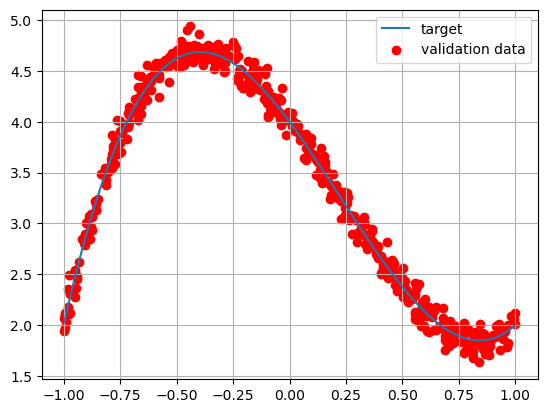

In [16]:
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(150, activation = 'relu'))
model.add(Dense(100, activation = 'relu'))
model.add(Dense(50, activation = 'relu'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [18]:
model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                     │ (None, 150)                 │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 100)                 │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,501 (80.08 KB)

 Trainable params: 20,501 (80.08 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x=x_train, y=y_train, 
          batch_size=50, epochs=50,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid), verbose=0)

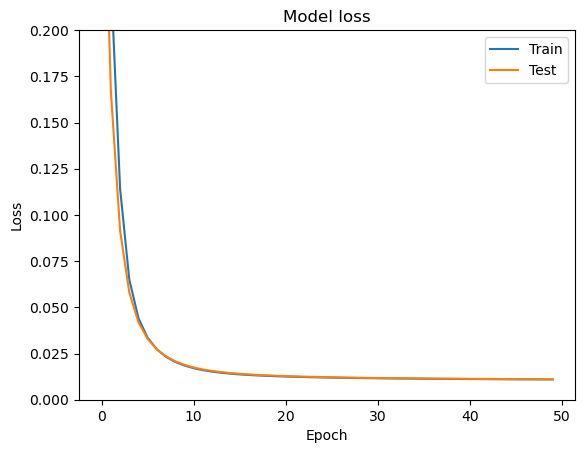

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim(0, 0.2)
plt.legend(['Train', 'Test'], loc='best')
plt.show()

Possiamo osservare come l'errore sia una funzione sostanzialmente monotona decrescente del numero di epoche, sia per quanto riguarda la loss di training che quella di test. Dopo una certa soglia, però, questo si appiattisce, indicando l'inutilità di aumentare il numero di epochs senza variare gli altri parametri.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


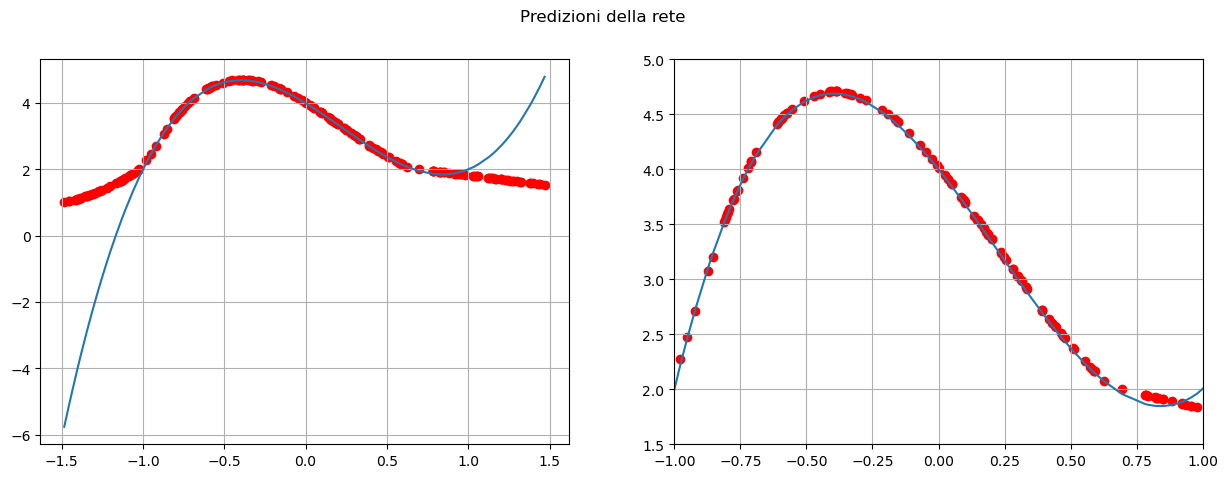

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

x_predicted = np.random.uniform(-1.5, 1.5, 200)
y_predicted = model.predict(x_predicted)
axes[0].scatter(x_predicted, y_predicted, color='r')
axes[1].scatter(x_predicted, y_predicted, color='r')
x_predicted.sort()
y_target = coeffs[0] + coeffs[1]*x_predicted + coeffs[2]*x_predicted*x_predicted + coeffs[3]*x_predicted*x_predicted*x_predicted
axes[0].plot(x_predicted, y_target)
axes[0].grid(True)


axes[1].plot(x_predicted, y_target)
axes[1].grid(True)
plt.xlim(-1, 1)
plt.ylim(1.5, 5)

plt.suptitle('Predizioni della rete')

plt.show()

Dai grafici possiamo apprezzare come il modello riesca a predire piuttosto bene i dati all'interno del suo dominio di training, ma fallisca miseramente al di fuori di esso. Questo certifica l'incapacità delle reti neurali di estrapolare al di fuori dei dati su cui sono state allenate.

Ho notato che le funzioni di attivazioni non limitate come la **relu** sono quelle che restituivano i migliori risultati.

Allo stesso modo, provando a sostituire lo **sgd** con altri optimizers come **adagrad**, ho notato che la concavità della curva di decresita della loss diveniva negativa nella prima parte di training, indicando una decrescita meno rapida, oltre a raggiungere valori finali di loss peggiori.

Per quanto riguarda la struttura della rete, aggiungere troppi layer o troppi neuroni peggiora significativamnte le performance da un punto di vista del tempo di esecuzione, e non porta a miglioramenti nel risultato finale, spesso predicendo il modello in maniera peggiore di quanto fatto dalla struttura della rete che ho scelto di mantenere. Allo stesso tempo, ridurre di troppo questi parametri porta a un fitting più grossolano: per certi valori particolarmente bassi ho addirittura trovato predizioni che seguivano linee spezzate invece che la curva dei dati reali.

Infine, mi sono accorto che i risultati migliori sono stati trovati quando il numero di neuroni varia significativamente tra i diversi layer.

## <span style="color:blue">  Exercise 11.3 </span>

In [22]:
np.random.seed(0)
x_train = np.random.uniform(-1.5, 1.5, 5000)
y_train = np.random.uniform(-1.5, 1.5, 5000)
x_valid = np.random.uniform(-1.5, 1.5, 500)
y_valid = np.random.uniform(-1.5, 1.5, 500)
f_target = np.sin(x_valid*x_valid + y_valid*y_valid)

sigma = 0.2
f_train = np.random.normal(np.sin(x_train*x_train + y_train*y_train), sigma) # actual measures from which we want to guess regression parameters
f_valid = np.random.normal(f_target, sigma)

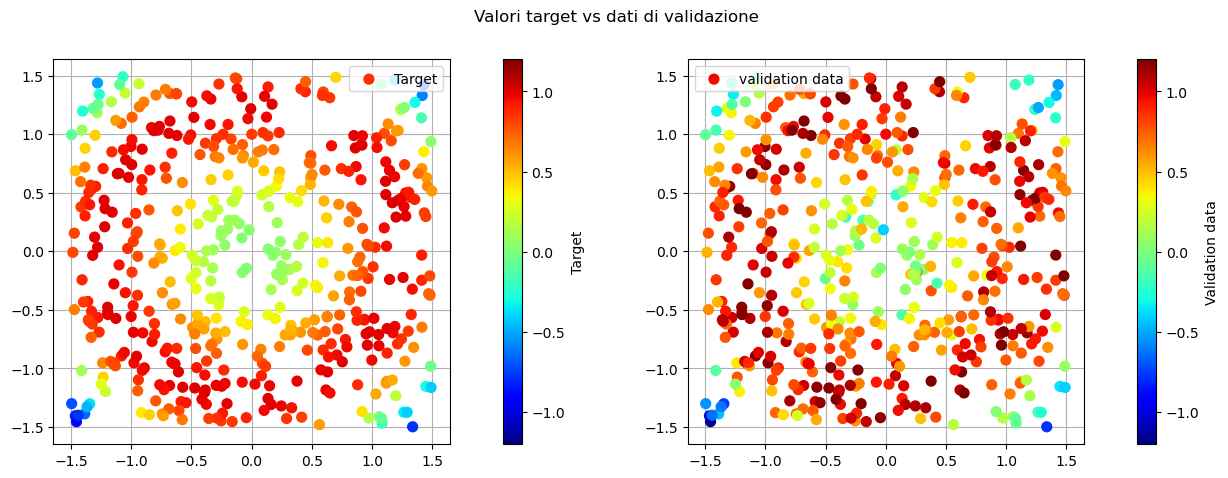

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

scatter_T = axes[0].scatter(x_valid, y_valid, c=f_target, cmap='jet', s=50, zorder=2, vmin = -1.2, vmax = 1.2, label='Target')
cbar_T = plt.colorbar(scatter_T, pad=0.1)
cbar_T.set_label('Target') 
axes[0].legend()
axes[0].grid(True)


scatter_e = axes[1].scatter(x_valid, y_valid, c=f_valid, cmap='jet', s=50, zorder=2, vmin = -1.2, vmax = 1.2, label='validation data')
cbar_E = plt.colorbar(scatter_e, pad=0.1)
cbar_E.set_label('Validation data')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Valori target vs dati di validazione")


plt.plot();

In [24]:
model = tf.keras.Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(150, activation = 'relu'))
model.add(Dense(100, activation = 'relu'))
model.add(Dense(20, activation = 'relu'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [25]:
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                     │ (None, 150)                 │             450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 100)                 │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 20)                  │           2,020 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,591 (68.71 KB)

 Trainable params: 17,591 (68.71 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
bsize = 32

X_train = np.column_stack((x_train, y_train))
X_valid = np.column_stack((x_valid, y_valid))

history = model.fit(x=X_train, y=f_train, 
          batch_size=bsize, epochs=50, 
          validation_data=(X_valid, f_valid), verbose=0)

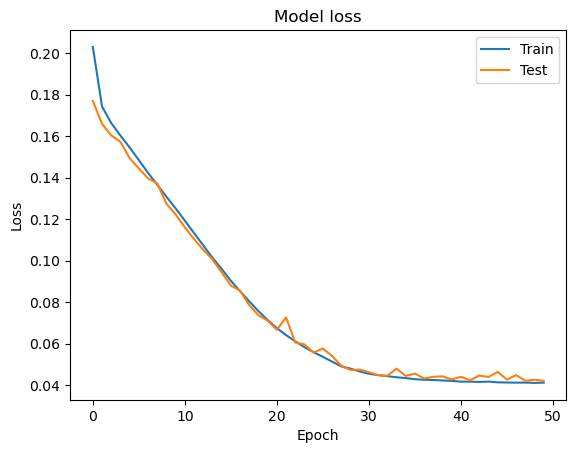

In [51]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


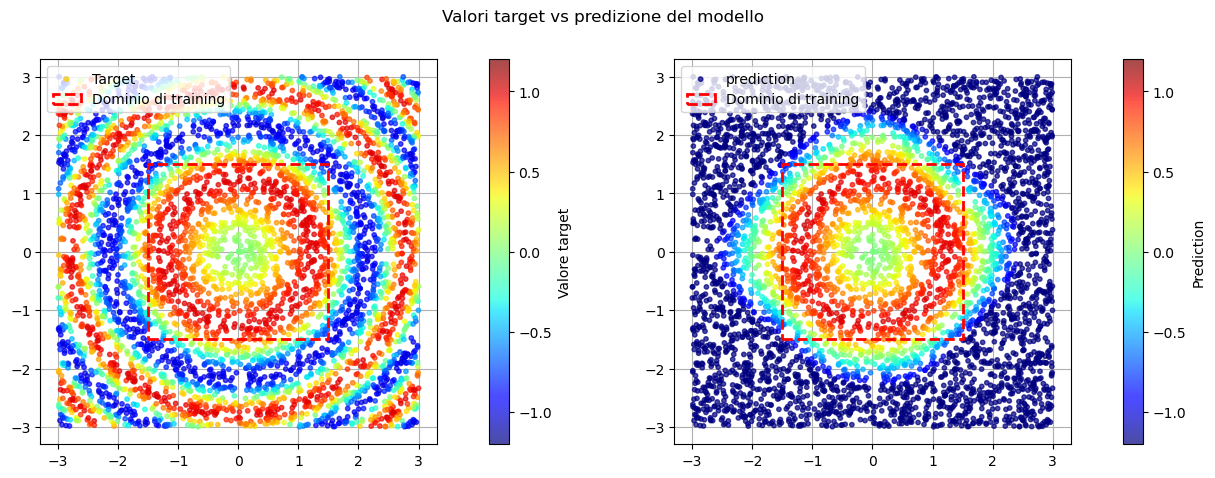

In [27]:
import matplotlib.patches as patches
x_predicted = np.random.uniform(-3, 3, 5000)
y_predicted = np.random.uniform(-3, 3, 5000)

f_target = np.sin(x_predicted*x_predicted + y_predicted*y_predicted)

data_predicted = np.column_stack((x_predicted, y_predicted))
f_predicted = model.predict(data_predicted).flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

scatter_T = axes[0].scatter(x_predicted, y_predicted, c=f_target, cmap='jet', s=10, zorder=2, vmin = -1.2, vmax = 1.2, label='Target', alpha = 0.7)
cbar_T = plt.colorbar(scatter_T, pad=0.1)
cbar_T.set_label('Valore target') 
rect1 = patches.Rectangle((-1.5, -1.5), 3, 3, linewidth=2, edgecolor='red', facecolor='none', linestyle='--', zorder=3, label='Dominio di training')
axes[0].add_patch(rect1)
axes[0].legend()
axes[0].grid(True)


scatter_e = axes[1].scatter(x_predicted, y_predicted, c=f_predicted, cmap='jet', s=10, zorder=2, vmin = -1.2, vmax = 1.2, label='prediction', alpha = 0.7)
cbar_E = plt.colorbar(scatter_e, pad=0.1)
cbar_E.set_label('Prediction')
rect2 = patches.Rectangle((-1.5, -1.5), 3, 3, linewidth=2, edgecolor='red', facecolor='none', linestyle='--', zorder=3, label='Dominio di training')
axes[1].add_patch(rect2)
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Valori target vs predizione del modello")


plt.plot();

## <span style="color:black">  Visualizzazione 3D </span>

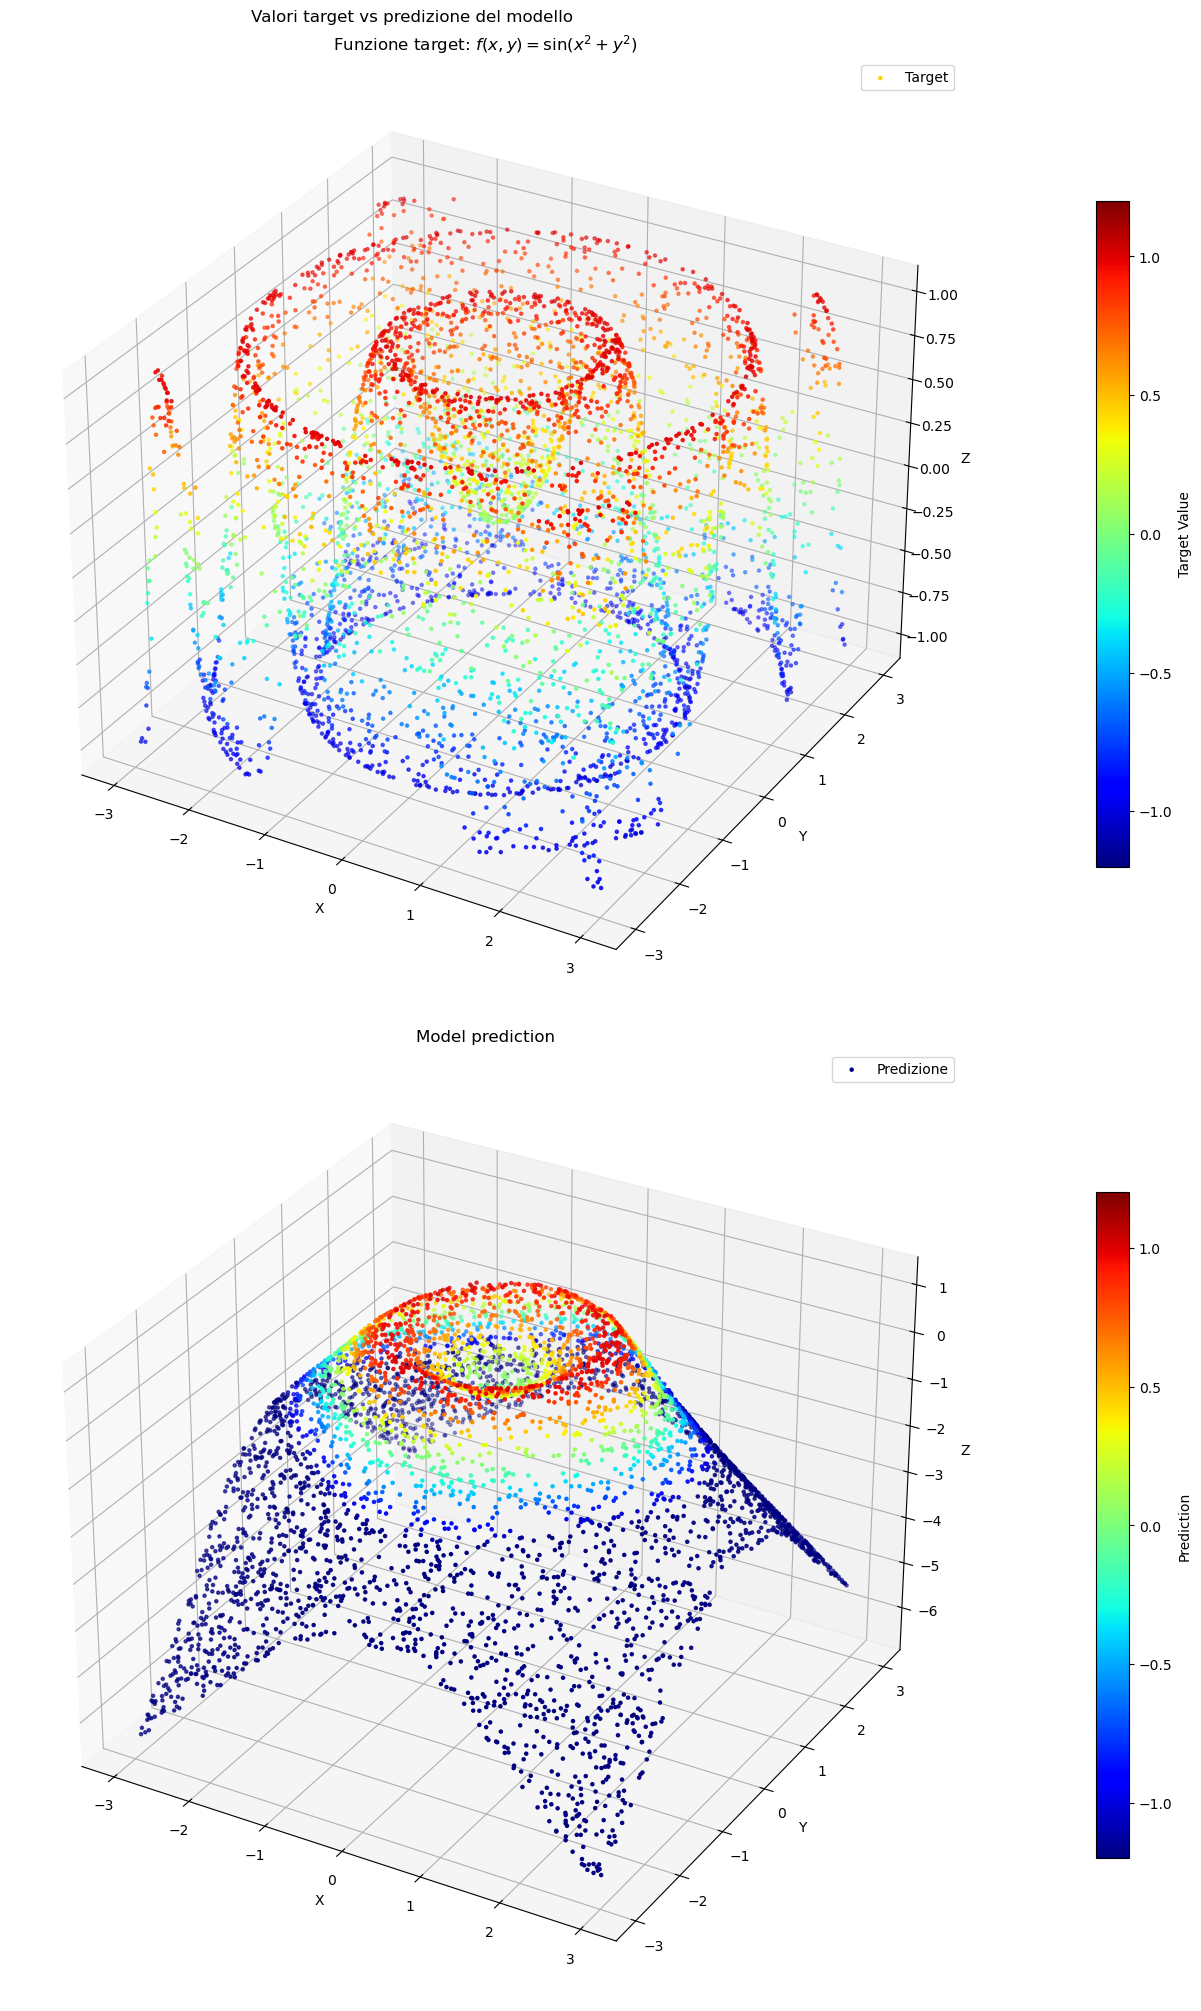

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(16, 20), subplot_kw={'projection': '3d'}, layout='constrained')
axes = axes.flatten()

scatter_T = axes[0].scatter(x_predicted, y_predicted, f_target, c=f_target, cmap='jet', s=5, zorder=2, vmin=-1.2, vmax=1.2, label='Target')

cbar_T = plt.colorbar(scatter_T, ax=axes[0], pad=0.1, shrink=0.7)
cbar_T.set_label('Target Value') 

axes[0].set_title(r'Funzione target: $f(x,y) = \sin(x^2 + y^2)$')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_zlabel('Z')
axes[0].legend()

scatter_e = axes[1].scatter(x_predicted, y_predicted, f_predicted, c=f_predicted, cmap='jet', s=5, zorder=2, vmin=-1.2, vmax=1.2, label='Predizione')
cbar_E = plt.colorbar(scatter_e, ax=axes[1], pad=0.1, shrink=0.7)
cbar_E.set_label('Prediction')

axes[1].set_title('Model prediction')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_zlabel('Z')
axes[1].legend()

plt.suptitle("Valori target vs predizione del modello")

plt.show()

Anche per questo esercizio possiamo apprezzare l'efficacia della rete nel ricostruire la funzione all'interno del dominio di training.